# TP2 - Clase 3
## Detector de maximo enfoque en video usando analisis espectral

**Alumno:** Facundo Manuel Quiroga

## Objetivo

Detectar automaticamente el frame mas enfocado de un video usando una metrica en frecuencia (FFT).

Experimentos realizados:

1. Medicion de enfoque sobre el frame completo.
2. Medicion de enfoque sobre una ROI central.
3. Deteccion automatica del maximo enfoque.
4. Visualizacion de una matriz de enfoque superpuesta.
5. Unsharp masking para expandir artificialmente la zona enfocada.

## Idea usada

Una imagen enfocada suele tener mas contenido de alta frecuencia que una desenfocada.
Para medir eso use una metrica del paper **Image Sharpness Measure for Blurred Images in Frequency Domain**.

Pasos de la metrica FM:

1. Calcular FFT 2D de la imagen.
2. Centrar el espectro con fftshift.
3. Obtener magnitud del espectro.
4. Calcular maximo del espectro, M.
5. Definir umbral: thres = M / 1000.
6. Contar pixeles con magnitud mayor al umbral.
7. Normalizar por tamano de imagen.

$$
FM = \frac{TH}{M \times N}
$$

donde TH es el numero de componentes espectrales arriba del umbral.

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Configuración inicial

En esta sección se define la ruta del video y algunos parámetros globales del análisis.

In [19]:
VIDEO_PATH = "focus_video.mov"

# ROI central: porcentaje del area total
ROI_AREA_RATIO = 0.10   # 0.05 o 0.10 segun consigna

# Factor del paper: thres = max(AF) / THRESH_DIVISOR
THRESH_DIVISOR = 1000.0

# Grilla para matriz de enfoque local
GRID_ROWS = 7
GRID_COLS = 7

# Parametros para unsharp masking
UNSHARP_K = 1.0
UNSHARP_SIGMA = 1.2

## Funciones auxiliares

En esta parte arme funciones chicas para poder reutilizar codigo y dejar mas limpia la notebook.

Se implementan funciones para:

- convertir a escala de grises,
- calcular la metrica espectral de enfoque,
- obtener una ROI central,
- procesar todos los frames del video,
- generar una matriz de enfoque local,
- aplicar unsharp masking.

In [20]:
def to_gray(frame):
    if len(frame.shape) == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()


def focus_measure_frequency(gray_img, thresh_divisor=1000.0):
    """
    Implementacion de la metrica FM del paper.
    Entrada: imagen en escala de grises
    Salida: valor escalar de enfoque
    """
    gray = gray_img.astype(np.float32)

    F = np.fft.fft2(gray)
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)

    max_val = np.max(AF)
    if max_val == 0:
        return 0.0

    thres = max_val / float(thresh_divisor)
    TH = np.sum(AF > thres)

    M, N = gray.shape
    FM = TH / (M * N)
    return float(FM)


def get_center_roi(gray_img, area_ratio=0.10):
    """
    Devuelve una ROI central cuyo area es area_ratio del area total.
    Para simplificar, se toma una ROI cuadrada.
    """
    h, w = gray_img.shape
    total_area = h * w
    roi_area = total_area * area_ratio
    side = int(np.sqrt(roi_area))

    side = max(1, min(side, h, w))

    y1 = (h - side) // 2
    x1 = (w - side) // 2
    y2 = y1 + side
    x2 = x1 + side

    return gray_img[y1:y2, x1:x2], (x1, y1, x2, y2)


def unsharp_mask(gray_img, sigma=1.2, k=1.0):
    """
    Unsharp masking:
    g = f + k * (f - f_blur)
    """
    gray = gray_img.astype(np.float32)
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
    sharp = gray + k * (gray - blur)
    sharp = np.clip(sharp, 0, 255).astype(np.uint8)
    return sharp


def read_video_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(
            f"No se pudo abrir el video: {video_path}. Revisa ruta y cwd."
        )

    frames = []
    grays = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
        grays.append(to_gray(frame))

    cap.release()

    if len(frames) == 0:
        raise ValueError("El video se abrio pero no se pudieron leer frames")

    return frames, grays


def compute_focus_series(gray_frames, thresh_divisor=1000.0):
    return [focus_measure_frequency(img, thresh_divisor=thresh_divisor) for img in gray_frames]


def compute_roi_focus_series(gray_frames, area_ratio=0.10, thresh_divisor=1000.0):
    metrics = []
    rois = []
    boxes = []

    for img in gray_frames:
        roi, box = get_center_roi(img, area_ratio)
        fm = focus_measure_frequency(roi, thresh_divisor=thresh_divisor)
        metrics.append(fm)
        rois.append(roi)
        boxes.append(box)

    return metrics, rois, boxes


def local_focus_map(gray_img, rows=7, cols=7, thresh_divisor=1000.0):
    """
    Divide la imagen en una grilla y calcula FM en cada celda.
    """
    h, w = gray_img.shape
    cell_h = h // rows
    cell_w = w // cols

    fmap = np.zeros((rows, cols), dtype=np.float32)

    for r in range(rows):
        for c in range(cols):
            y1 = r * cell_h
            x1 = c * cell_w

            if r == rows - 1:
                y2 = h
            else:
                y2 = (r + 1) * cell_h

            if c == cols - 1:
                x2 = w
            else:
                x2 = (c + 1) * cell_w

            patch = gray_img[y1:y2, x1:x2]
            fmap[r, c] = focus_measure_frequency(patch, thresh_divisor=thresh_divisor)

    return fmap


def draw_focus_grid(frame_bgr, fmap):
    """
    Superpone una grilla coloreada segun la intensidad relativa del foco.
    """
    out = frame_bgr.copy()
    h, w = out.shape[:2]
    rows, cols = fmap.shape
    cell_h = h // rows
    cell_w = w // cols

    fmin = np.min(fmap)
    fmax = np.max(fmap)
    denom = (fmax - fmin) if (fmax > fmin) else 1.0

    for r in range(rows):
        for c in range(cols):
            y1 = r * cell_h
            x1 = c * cell_w

            if r == rows - 1:
                y2 = h
            else:
                y2 = (r + 1) * cell_h

            if c == cols - 1:
                x2 = w
            else:
                x2 = (c + 1) * cell_w

            val = (fmap[r, c] - fmin) / denom

            # Verde mas intenso cuanto mayor foco
            color = (0, int(255 * val), 0)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)

    return out

## Lectura del video

In [21]:
frames_bgr, frames_gray = read_video_frames(VIDEO_PATH)
len(frames_bgr), frames_gray[0].shape

(171, (360, 640))

## Visualización de un frame de ejemplo

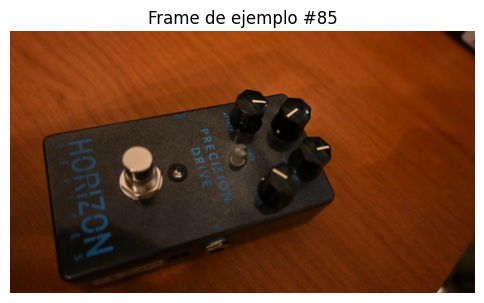

In [22]:
example_idx = len(frames_bgr) // 2

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(frames_bgr[example_idx], cv2.COLOR_BGR2RGB))
plt.title(f"Frame de ejemplo #{example_idx}")
plt.axis("off")
plt.show()

## Experimento 1: medición de enfoque sobre todo el frame

Se calcula la métrica `FM` para cada frame completo del video.
Luego se grafica la evolución de la métrica en función del número de frame y se detecta automáticamente el máximo.

In [23]:
focus_full = compute_focus_series(frames_gray, thresh_divisor=THRESH_DIVISOR)

best_full_idx = int(np.argmax(focus_full))
best_full_value = focus_full[best_full_idx]

print(f"Frame con maximo enfoque (frame completo): {best_full_idx}")
print(f"Valor FM maximo: {best_full_value:.6f}")

Frame con maximo enfoque (frame completo): 109
Valor FM maximo: 0.028624


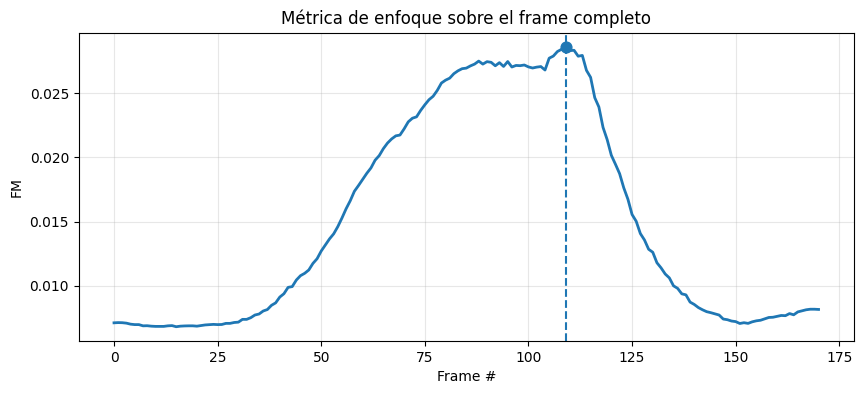

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(focus_full, linewidth=2)
plt.axvline(best_full_idx, linestyle="--")
plt.scatter([best_full_idx], [best_full_value], s=60)
plt.xlabel("Frame #")
plt.ylabel("FM")
plt.title("Métrica de enfoque sobre el frame completo")
plt.grid(True, alpha=0.3)
plt.show()

## Visualización del frame de máximo enfoque global

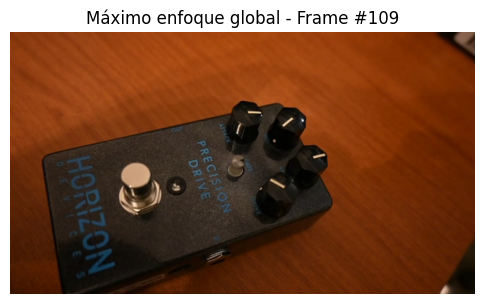

In [25]:
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(frames_bgr[best_full_idx], cv2.COLOR_BGR2RGB))
plt.title(f"Máximo enfoque global - Frame #{best_full_idx}")
plt.axis("off")
plt.show()

## Experimento 2: medición de enfoque sobre una ROI central

Se define una región de interés cuadrada en el centro del frame, con un área equivalente al 10% del área total de la imagen.
Sobre esa ROI se calcula la misma métrica `FM` para todos los frames.

In [26]:
focus_roi, rois, roi_boxes = compute_roi_focus_series(
    frames_gray, area_ratio=ROI_AREA_RATIO, thresh_divisor=THRESH_DIVISOR
)

best_roi_idx = int(np.argmax(focus_roi))
best_roi_value = focus_roi[best_roi_idx]

print(f"Frame con maximo enfoque en ROI: {best_roi_idx}")
print(f"Valor FM maximo en ROI: {best_roi_value:.6f}")

Frame con maximo enfoque en ROI: 111
Valor FM maximo en ROI: 0.347572


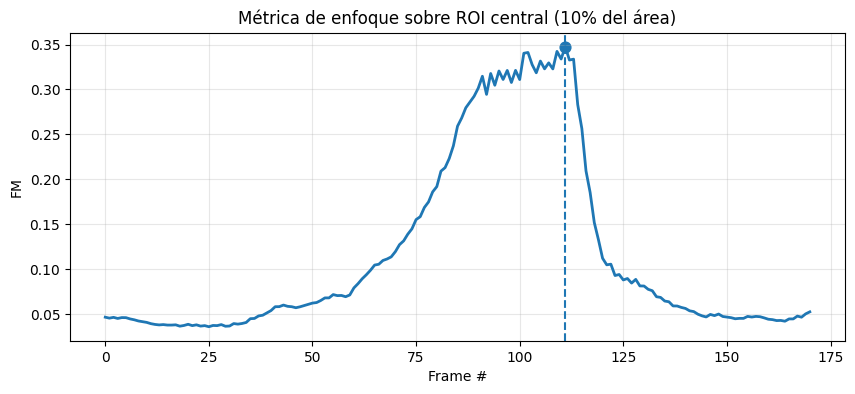

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(focus_roi, linewidth=2)
plt.axvline(best_roi_idx, linestyle="--")
plt.scatter([best_roi_idx], [best_roi_value], s=60)
plt.xlabel("Frame #")
plt.ylabel("FM")
plt.title(f"Métrica de enfoque sobre ROI central ({int(ROI_AREA_RATIO*100)}% del área)")
plt.grid(True, alpha=0.3)
plt.show()

## ROI central superpuesta sobre el frame de máximo enfoque

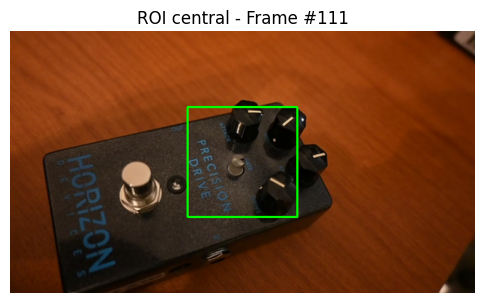

In [28]:
frame_roi_vis = frames_bgr[best_roi_idx].copy()
x1, y1, x2, y2 = roi_boxes[best_roi_idx]
cv2.rectangle(frame_roi_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(frame_roi_vis, cv2.COLOR_BGR2RGB))
plt.title(f"ROI central - Frame #{best_roi_idx}")
plt.axis("off")
plt.show()

## Comparación entre las curvas de enfoque

Se comparan las dos mediciones:
- frame completo,
- ROI central.

Esto permite ver si el punto de máximo enfoque coincide en ambos casos o si la ROI aporta mayor sensibilidad sobre la región de interés.

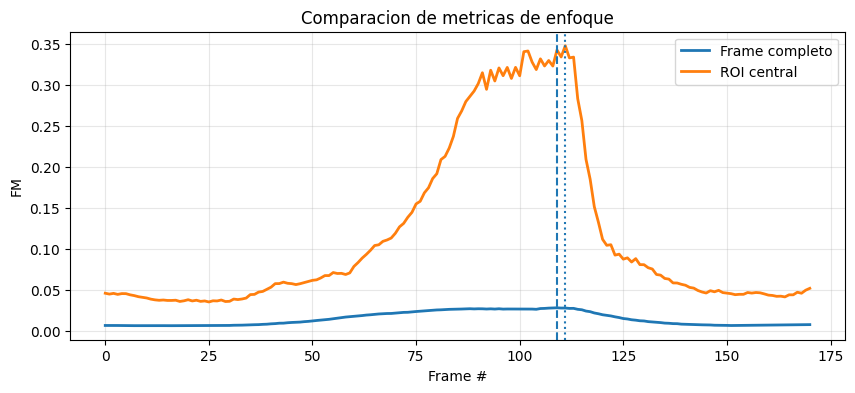

Diferencia entre maximos detectados: 2 frames


In [29]:
plt.figure(figsize=(10, 4))
plt.plot(focus_full, label="Frame completo", linewidth=2)
plt.plot(focus_roi, label="ROI central", linewidth=2)
plt.axvline(best_full_idx, linestyle="--")
plt.axvline(best_roi_idx, linestyle=":")
plt.xlabel("Frame #")
plt.ylabel("FM")
plt.title("Comparacion de metricas de enfoque")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

delta = abs(best_full_idx - best_roi_idx)
print(f"Diferencia entre maximos detectados: {delta} frames")

## Matriz de enfoque local superpuesta sobre un frame

Como visualización adicional, se divide el frame en una grilla regular y se calcula la métrica `FM` en cada celda.
Luego se superpone la grilla sobre la imagen, coloreando cada región según su nivel relativo de enfoque.

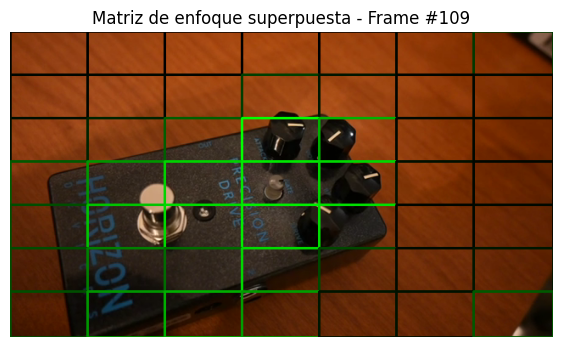

In [30]:
frame_for_map_idx = best_full_idx
fmap = local_focus_map(
    frames_gray[frame_for_map_idx],
    rows=GRID_ROWS,
    cols=GRID_COLS,
    thresh_divisor=THRESH_DIVISOR,
    )
frame_grid = draw_focus_grid(frames_bgr[frame_for_map_idx], fmap)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(frame_grid, cv2.COLOR_BGR2RGB))
plt.title(f"Matriz de enfoque superpuesta - Frame #{frame_for_map_idx}")
plt.axis("off")
plt.show()

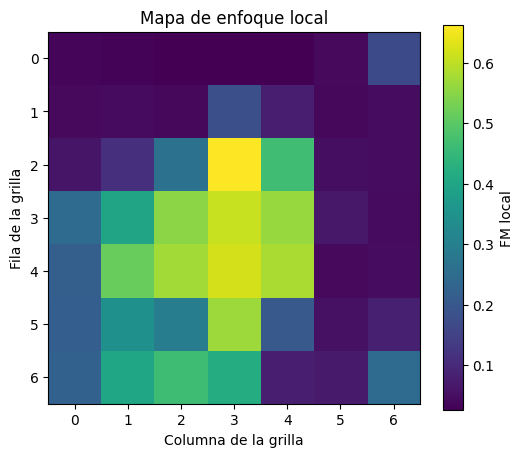

In [31]:
plt.figure(figsize=(6, 5))
plt.imshow(fmap, cmap="viridis")
plt.colorbar(label="FM local")
plt.title("Mapa de enfoque local")
plt.xlabel("Columna de la grilla")
plt.ylabel("Fila de la grilla")
plt.show()

## Unsharp masking

Se aplica *unsharp masking* al frame para realzar artificialmente las componentes de alta frecuencia y observar si esto expande la zona de enfoque.

La operación implementada es:

$$
g(x,y) = f(x,y) + k \cdot (f(x,y) - f_B(x,y))
$$

donde `f_B` es una versión suavizada de la imagen.

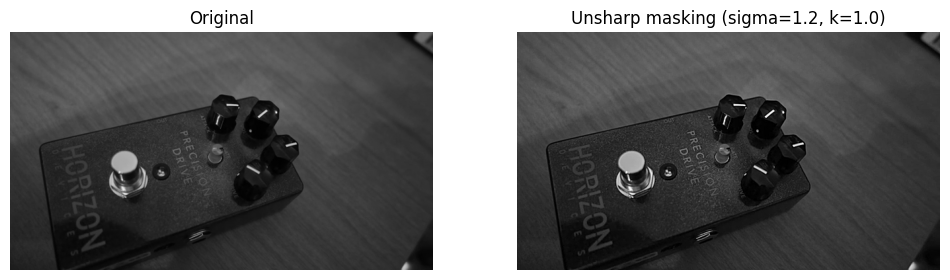

In [32]:
sharp_example = unsharp_mask(frames_gray[best_full_idx], sigma=UNSHARP_SIGMA, k=UNSHARP_K)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(frames_gray[best_full_idx], cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharp_example, cmap="gray")
plt.title(f"Unsharp masking (sigma={UNSHARP_SIGMA}, k={UNSHARP_K})")
plt.axis("off")

plt.show()

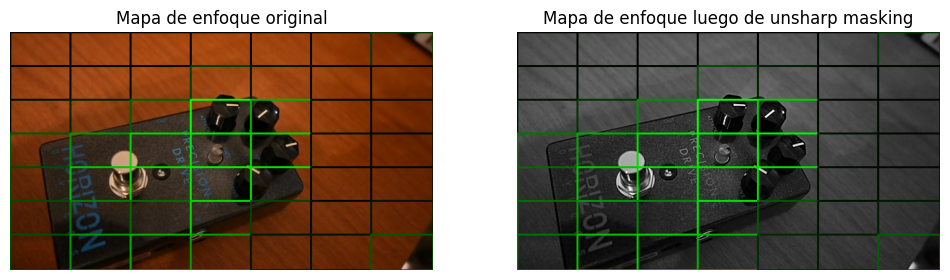

In [33]:
fmap_original = local_focus_map(
    frames_gray[best_full_idx],
    rows=GRID_ROWS,
    cols=GRID_COLS,
    thresh_divisor=THRESH_DIVISOR,
    )
fmap_sharp = local_focus_map(
    sharp_example,
    rows=GRID_ROWS,
    cols=GRID_COLS,
    thresh_divisor=THRESH_DIVISOR,
    )

frame_grid_original = draw_focus_grid(frames_bgr[best_full_idx], fmap_original)

sharp_bgr = cv2.cvtColor(sharp_example, cv2.COLOR_GRAY2BGR)
frame_grid_sharp = draw_focus_grid(sharp_bgr, fmap_sharp)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame_grid_original, cv2.COLOR_BGR2RGB))
plt.title("Mapa de enfoque original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(frame_grid_sharp, cv2.COLOR_BGR2RGB))
plt.title("Mapa de enfoque luego de unsharp masking")
plt.axis("off")

plt.show()

## Conclusiones

En las pruebas se ve que la metrica espectral funciona bien para encontrar el mejor foco del video sin usar referencia.

Resultados principales:

1. El maximo de la curva FM marca un frame nitido de forma estable.
2. Midiendo solo ROI central, la deteccion puede cambiar un poco pero sigue una tendencia similar.
3. El mapa local por grilla ayuda a ver en que zonas hay mas nitidez.
4. Con unsharp masking suben las altas frecuencias y el mapa muestra mayor respuesta en varias celdas.